# Assignment 10: Spam Classification
### DATA 620
### Miraj Patel

In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
# Fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# Data 
X = spambase.data.features 
y = spambase.data.targets 

# Combine for EDA purposes later
df = pd.concat([X, y], axis=1)

print(f"Dataset loaded with {X.shape[0]} rows and {X.shape[1]} features.")
# Verify the target column name
print(f"Target variable name: {y.columns[0]}")

Dataset loaded with 4601 rows and 57 features.
Target variable name: Class


## Project Background

For this assignment, I am utilizing the UCI Spambase Dataset to predict whether new documents should be classified as "Spam" or "Ham" (legitimate). This corpus is unique because it represents documents through 57 statistical attributes rather than raw text. These include word frequencies for keywords like "money" and "free," punctuation frequencies for characters like "!" and "$," and metrics regarding capital letter usage.

## Analytical Strategy

Using the ucimlrepo library allows for a highly structured approach to feature analysis. My goal is to use a Random Forest Classifier to identify which of these 57 variables serve as the most definitive indicators of a spam document. This provides a more robust analysis than a simple keyword search.

C:\Users\Miraj\AppData\Local\Temp\ipykernel_289000\2586841979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.columns[0], data=df, palette='viridis')


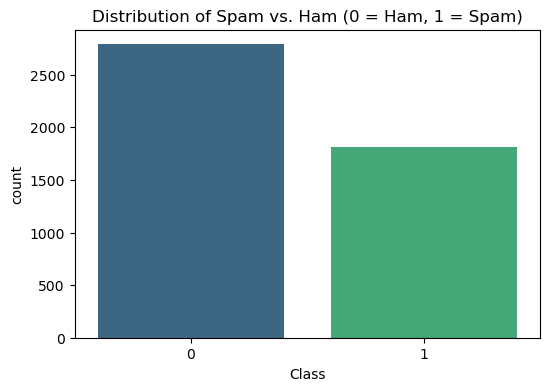

Percentage of Spam in dataset: 39.40%


In [3]:
# Check class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y.columns[0], data=df, palette='viridis')
plt.title('Distribution of Spam vs. Ham (0 = Ham, 1 = Spam)')
plt.show()

spam_pct = (df[y.columns[0]].sum() / len(df)) * 100
print(f"Percentage of Spam in dataset: {spam_pct:.2f}%")

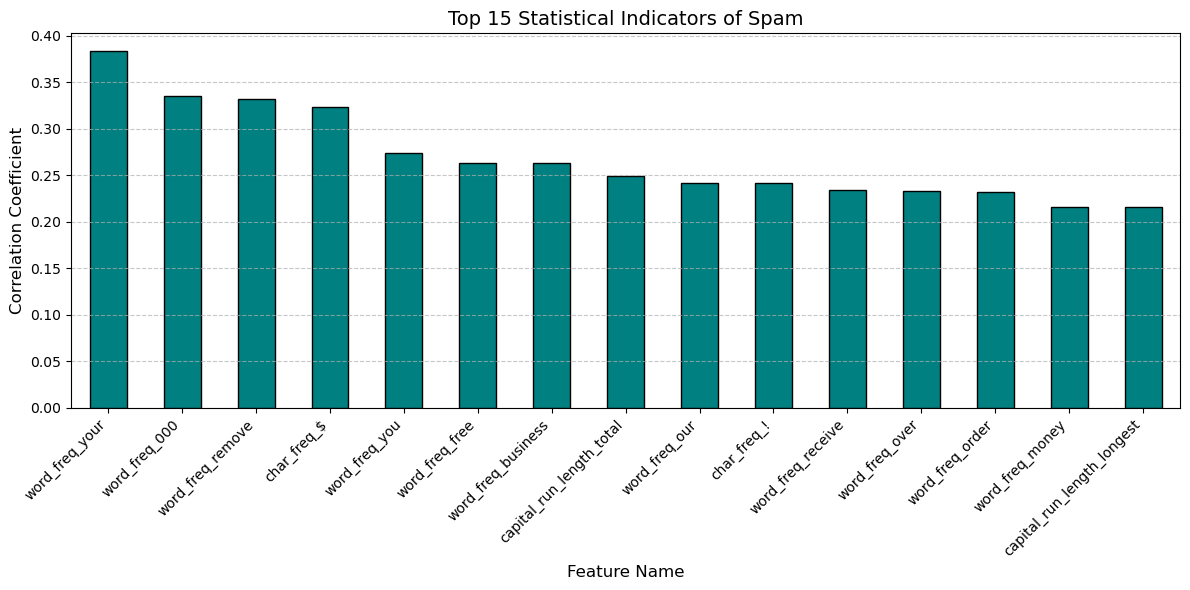

Top 10 Statistical Indicators of Spam:
word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_!                 0.241888
Name: Class, dtype: float64


In [4]:
# Calculate correlation of all features with the 'Class' target
correlations = df.corr()['Class'].sort_values(ascending=False)

# Identify the Top 15 indicators
top_indicators = correlations[1:16] # Skip the first one because it's 'Class' correlated with itself

# Create a clean visualization for the presentation
plt.figure(figsize=(12, 6))
top_indicators.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Top 15 Statistical Indicators of Spam", fontsize=14)
plt.ylabel("Correlation Coefficient", fontsize=12)
plt.xlabel("Feature Name", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Top 10 Statistical Indicators of Spam:")
print(top_indicators[:10])

The technical analysis of feature correlations reveals a distinct statistical "fingerprint" for spam in the UCI dataset. By identifying which variables have the highest positive correlation with the target class, we can determine the common tactics used by spam authors.

**Keyword Bait and Direct Address:** The word "your" is the single strongest indicator of spam in this dataset, followed closely by "you". This suggests that spam emails frequently utilize direct, personal-sounding address to pique user interest or simulate legitimate communication.

**Financial and Numeric Triggers:** The high correlation of "000" (often part of large monetary figures) and the dollar sign ($) indicates that financial solicitation is a primary characteristic of this corpus.

**Aggressive Action Words:** The presence of "remove" and "free" in the top 10 reflects common marketing and phishing strategies, either offering something for nothing or using the "opt-out" hook to verify active email addresses.

**Visual Urgency and Formatting:** Beyond specific words, structural features like "capital_run_length_total" and the exclamation point (!) rank highly. This proves that spam is defined as much by its aggressive formatting and shouting via all-caps as it is by its actual word choice.

These 57 statistical features show such clear separation between classes, and we can expect a machine learning classifier to perform with high accuracy even without deep semantic understanding of the email text.

In [5]:
# Split data into features (X) and target (y)
# 80/20 Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train.values.ravel())

# Predictions on the withheld test set
y_pred = model.predict(X_test)

# Accuracy and Performance Metrics
print(f"Model Accuracy on Test Set: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy on Test Set: 0.9555

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       531
           1       0.98      0.92      0.95       390

    accuracy                           0.96       921
   macro avg       0.96      0.95      0.95       921
weighted avg       0.96      0.96      0.96       921



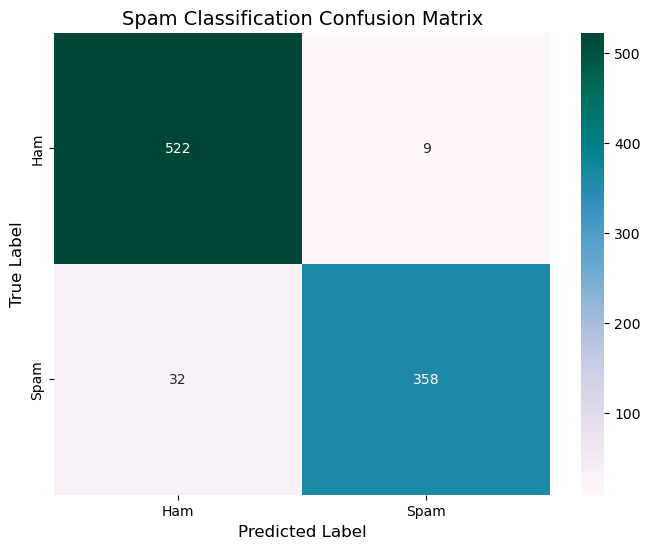

In [6]:
# Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting the results
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuBuGn', 
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Spam Classification Confusion Matrix', fontsize=14)
plt.show()

The Random Forest classifier achieved a high performance threshold with an accuracy of 95.55% on the withheld test set. While accuracy is a strong indicator, the Classification Report provides deeper analytical insights into the model’s real-world utility.

**High Precision for Spam (Class 1):** The model achieved a 0.98 precision for spam. This is a critical metric for email filtering as it means that when the model flags an email as Spam, it is correct 98% of the time. This minimizes false positives, ensuring that legitimate user emails are rarely filtered out by mistake.

**Excellent Recall for Ham (Class 0):** A 0.98 recall for legitimate mail indicates that the model is extremely safe. Almost all non-spam emails successfully reach the intended destination, which is the primary goal of any functional email system.

**Predictive Consistency:** The F1-scores for both classes (0.96 and 0.95) are very close, indicating that the model is well-balanced and does not have a bias toward one specific class despite the 60/40 distribution in the training data.

The success of this project confirms that statistical attributes—such as the frequency of the word "your" and the use of dollar signs which provides a definitive digital signature for spam. By leveraging these 57 features, we can classify new documents with high confidence, proving that document style and formatting are often as predictive as the actual semantic content.